In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s


In [3]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0,]
b_coeffs = [3,]
#get bpmeth opbject
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
#expansion.plot_components()
# plt.xlabel('s')
# plt.xlim((0,1))

/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:96: UserWarning: The laplacian could not be evaluated
  warnings.warn("The laplacian could not be evaluated")


Scalar potential phi(x,y,s): 3*y
Scalar potential phi at (0.4,0.2,0.5): 0.6000000000000001


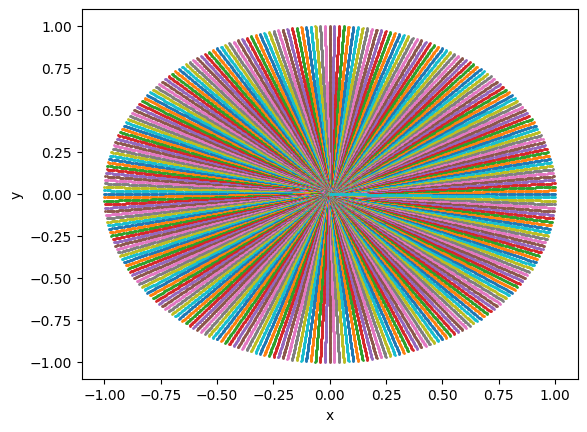

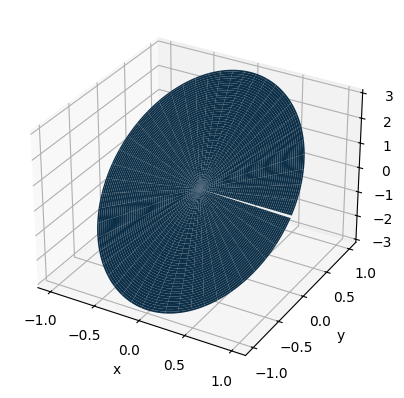

In [4]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define r, theta, s axes to convert the symbolic expression of phi into a numerical array
# npoints=201
# xa= np.linspace(-1,1,npoints) 
# ya=np.linspace(-1,1,npoints)
rmin, rmax, nr = 0.001, 1.001, 200
ntheta = 300
rr = np.linspace(rmin, rmax, nr)
tt = np.arange(ntheta)/ntheta*2*np.pi
ss = np.linspace(-1,1, 40)

rarr, tarr, sarr = np.meshgrid(rr, tt, ss, indexing='ij')
xarr = rarr*np.cos(tarr)
yarr = rarr*np.sin(tarr)
#make a 3d plot of phi as a function of x and y for a fixed s
plt.plot(xarr[:,:,0], yarr[:,:,0], 'o', markersize=1)
plt.xlabel("x")
plt.ylabel("y")
P = phi_func(xarr[:,:,0], yarr[:,:,0], 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xarr[:,:,0], yarr[:,:,0],P)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [5]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)#with lambdify=False
# Evaluate on grid
#X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(xarr, yarr, sarr)
By_ana = By_func(xarr, yarr, sarr)
Bs_ana = Bs_func(xarr, yarr, sarr)

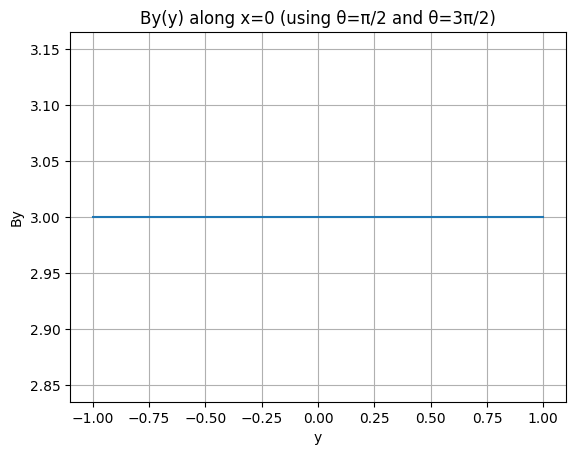

In [6]:
#Plot By as a function of y for x=0
islice = 20   # choose an s index
# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
By_pos = By_ana[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
By_neg = By_ana[:, itheta_neg, islice]

# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
By_all = np.concatenate([By_neg, By_pos])

order = np.argsort(y_all)
y_all = y_all[order]
By_all = By_all[order]

plt.plot(y_all, By_all)
plt.xlabel("y")
plt.ylabel("By")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")
plt.grid(True)


In [7]:
Ax, Ay, As = expansion.get_A(lambdify=True)
#print("Ax:", Ax, "Ay:", Ay, "As:", As)#with lambdify False
Ax_ana = Ax(xarr, yarr, sarr)
Ay_ana = Ay(xarr, yarr, sarr)
As_ana = As(xarr, yarr, sarr)


In [10]:
#then take the curl of A from finite differences and compare with the original B field
def curl_cylindrical_from_cartesian(Ax, Ay, Az, rarr, tarr, sarr):
    """
    Compute curl(A) on a cylindrical grid (r, theta, s),
    where A is given in Cartesian components (Ax, Ay, Az).
    """

    # ---------------------------------------------------------
    # 1. Extract axes and spacings
    # ---------------------------------------------------------
    r_axis     = rarr[:,0,0]
    theta_axis = tarr[0,:,0]
    s_axis     = sarr[0,0,:]

    dr     = r_axis[1]     - r_axis[0]
    dtheta = theta_axis[1] - theta_axis[0]
    ds     = s_axis[1]     - s_axis[0]

    # ---------------------------------------------------------
    # 2. Convert A from Cartesian → cylindrical components
    # ---------------------------------------------------------
    cos_t = np.cos(tarr)
    sin_t = np.sin(tarr)

    Ar     =  Ax*cos_t + Ay*sin_t
    Atheta = -Ax*sin_t + Ay*cos_t
    Az_cyl =  Az

    # ---------------------------------------------------------
    # 3. Compute partial derivatives
    # ---------------------------------------------------------
    dAr_dtheta     = np.gradient(Ar,     dtheta, axis=1)
    dAtheta_dtheta = np.gradient(Atheta, dtheta, axis=1)
    dAz_dtheta     = np.gradient(Az_cyl, dtheta, axis=1)

    dAr_dr     = np.gradient(Ar,     dr, axis=0)
    dAtheta_dr = np.gradient(Atheta, dr, axis=0)
    dAz_dr     = np.gradient(Az_cyl, dr, axis=0)

    dAr_dz     = np.gradient(Ar,     ds, axis=2)
    dAtheta_dz = np.gradient(Atheta, ds, axis=2)
    dAz_ds     = np.gradient(Az_cyl, ds, axis=2)

    # ---------------------------------------------------------
    # 4. Curl in cylindrical coordinates
    # ---------------------------------------------------------
    r = rarr

    curl_r = (1/r) * dAz_dtheta - dAtheta_dz
    curl_theta = dAr_dz - dAz_dr

    rAtheta = r * Atheta
    d_rAtheta_dr = np.gradient(rAtheta, dr, axis=0)

    curl_z = (1/r) * d_rAtheta_dr - (1/r) * dAr_dtheta

    # ---------------------------------------------------------
    # 5. Convert curl back to Cartesian components
    # ---------------------------------------------------------
    curl_x = curl_r*cos_t - curl_theta*sin_t
    curl_y = curl_r*sin_t + curl_theta*cos_t
    curl_s = curl_z

    return curl_x, curl_y, curl_s

curl_x, curl_y, curl_s = curl_cylindrical_from_cartesian(Ax_ana, Ay_ana, As_ana, rarr, tarr, sarr)
#print(curl_Ax.shape, Bx_ana.shape)
# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_x - Bx_ana)))
print("Max relative difference in By:", np.max(np.abs(curl_y - By_ana))/np.max(np.abs(By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_s - Bs_ana)))


Max difference in Bx: 0.03141477817210459
Max relative difference in By: 0.0002192203320262228
Max difference in Bs: 0.0


(200, 300, 40)
30


/tmp/fmarcoli/ipykernel_12470/1338873760.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.plot(truncatedxarr, (curl_x[position]-Bx_ana[position])/(Bx_ana[position]), label='Curl(A)_x -Bx')
/tmp/fmarcoli/ipykernel_12470/1338873760.py:10: RuntimeWarning: invalid value encountered in divide
  plt.plot(truncatedxarr, (curl_s[position]-Bs_ana[position])/(Bs_ana[position]), label='Curl(A)_s -Bs')


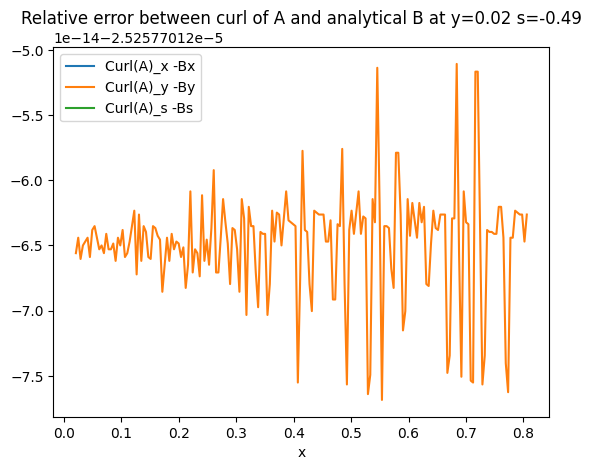

In [11]:
npoints=len(xarr)
print(xarr.shape)
truncatedxarr=xarr[5:npoints-1,30,10]#to avoid boundary effects from finite differences
#truncateds=sa[5:npoints-5]#to avoid boundary effects from finite differences
#position=(45, 54,slice(5,npoints-5))#x=0, y=0, all s
position=(slice(5,npoints-1), 30, 10)#all x, y=fixed, s=fixed
print(position[1])
plt.plot(truncatedxarr, (curl_x[position]-Bx_ana[position])/(Bx_ana[position]), label='Curl(A)_x -Bx')
plt.plot(truncatedxarr, (curl_y[position]-By_ana[position])/(By_ana[position]), label='Curl(A)_y -By')
plt.plot(truncatedxarr, (curl_s[position]-Bs_ana[position])/(Bs_ana[position]), label='Curl(A)_s -Bs')
#plt.ylim((np.min((curl_Ay[position]-By_ana[position])/By_ana[position]), np.max((curl_Ay[position]-By_ana[position])/By_ana[position])))
plt.legend()
plt.title('Relative error between curl of A and analytical B at y='+str(np.round(yarr[position][1],2)) +" s="+str(np.round(sarr[position][2],2)))
plt.xlabel('x')
plt.show()


Text(0.5, 0, 'x')

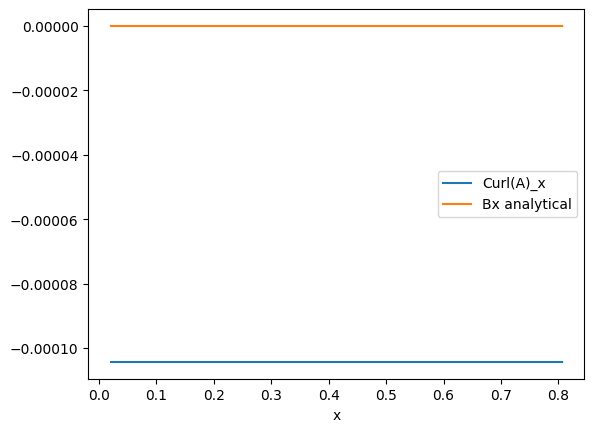

In [12]:
plt.plot(truncatedxarr, curl_x[position], label='Curl(A)_x')
plt.plot(truncatedxarr,Bx_ana[position], label='Bx analytical')
plt.legend()
plt.xlabel('x')

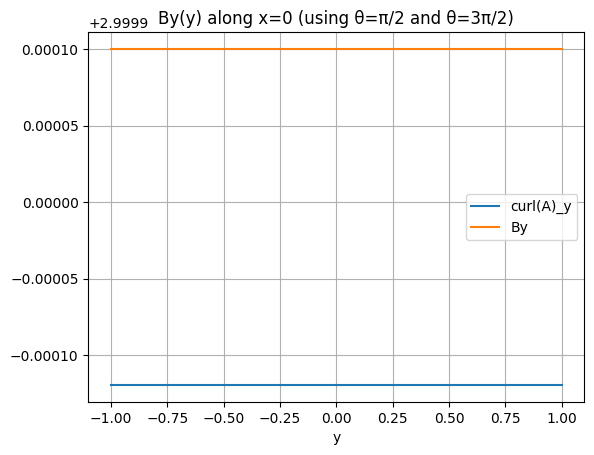

In [13]:

islice = 20   # choose an s index

# θ = π/2 → positive y
itheta_pos = np.argmin(np.abs(tt - np.pi/2))
y_pos = yarr[:,itheta_pos, islice]
curly_pos = curl_y[:, itheta_pos, islice]

# θ = 3π/2 → negative y
itheta_neg = np.argmin(np.abs(tt - 3*np.pi/2))
y_neg = yarr[:,itheta_neg, islice]
curly_neg = curl_y[:, itheta_neg, islice]

# Combine and sort
y_all = np.concatenate([y_neg, y_pos])
curly_all = np.concatenate([curly_neg, curly_pos])
order = np.argsort(y_all)
y_all = y_all[order]
curly_all = curly_all[order]

plt.plot(y_all, curly_all, label='curl(A)_y')
plt.plot(y_all, By_all, label='By')
plt.xlabel("y")
plt.title("By(y) along x=0 (using θ=π/2 and θ=3π/2)")

plt.legend()
plt.grid(True)


In [14]:
print("rmin=", rmin, "rmax=", rmax, "step=",(rmax-rmin)/nr)
nk=4
np.linspace(-nk,nk,2*nk+1)

rmin= 0.001 rmax= 1.001 step= 0.004999999999999999


array([-4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.])

/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fmarcoli/bpmeth/envbpmeth/lib64/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


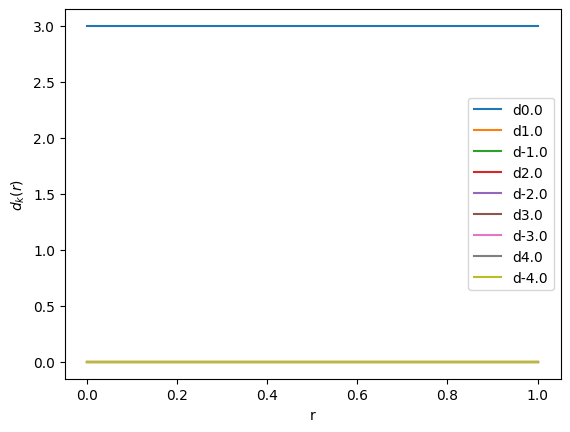

In [ ]:
def rt2xy(r,theta):
    return r*np.cos(theta),r*np.sin(theta) #cartesian positions of points on which i have the field B_func 
sindex=25
s_fixed=ss[sindex]
nk=4 #maximum abs of k
def ByiBx(x, y):#analytical definition of By + i*Bx at s=s_fixed
    return By_func(x, y, s_fixed) + 1j * Bx_func(x, y, s_fixed)
rr=np.linspace(rmin,rmax,nr)

def dkharmonics(ByiBx,rr=rr,nk=nk,ntheta=102):
   #radial positions
  out=np.empty((len(rr),2*nk+1),dtype=complex) #prepare to store dk's as functions of r0 
  theta=np.arange(ntheta)/ntheta*2*np.pi
  for ir,r in enumerate(rr):
    x,y=rt2xy(r,theta)
    b=ByiBx(x,y)
    d=np.fft.fft(b)/ntheta #discrete fourier coefficients: dk at this r0
    out[ir,0]=d[0]#k=0
    out[ir,1::2]=d[1:nk+1] #first "fourier frequencies" are for positive k, stored in odd indexes
    out[ir,2::2]=d[ntheta:ntheta-nk-1:-1]#the last ones are for negative frequencies (take them in reverse order), stored in even indexes
  return out

dkofr=dkharmonics(ByiBx=ByiBx, rr=rr)
#plot dk(r)
for ki in range(2*nk+1):
  if ki % 2 != 0: #odd array indexes are storing positive k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki], label='d'+str((ki+1)/2))
  else:#even idexes->negative k's
    plt.plot(rarr[:,0,sindex], dkofr[:,ki], label='d'+str(-ki/2))

plt.xlabel('r')
plt.ylabel('$d_k(r)$')
#plt.plot(rarr[:,0,sindex],dkofr[:,4], label='ppp')
plt.legend()
plt.show()


In [ ]:

def dklfit(dkofrarray,rr,nk, nl):
  polynomial=np.zeros((len(rr), 2*nk+1),dtype=complex)
  ka=np.linspace(-nk,nk,2*nk+1)
  for ir,r in enumerate(rr):
     polynomial[ir,0]=dkofrarray[ir,0]#for k=0 it would be divided by r0^0=1
     polynomial[ir,1::2]=dkofrarray[ir,1::2]/r**ka[nk+1 : 2*nk+1] #for positive k
     polynomial[ir,2::2]=dkofrarray[ir,1::2]/r**ka[0: nk] #for negative k
  dkl=np.zeros((2*nk+1, nl), dtype=complex)#different k along rows, different l along columns
  dkl[0,:]=np.polyfit(rr**2,polynomial[:,0],deg=nl-1)[::-1] #k=0, fit r^2 since the exponent is 2l
  dkl[1::2,:]=np.polyfit(rr**2, polynomial[:,1::2], deg=nl-1).T[::1]#positive k
  dkl[2::2,:]=np.polyfit(rr**2, polynomial[:,2::2], deg=nl-1).T[::1]#negative k
  return dkl 
nl=3
prdkl=dklfit(dkofr,rr=rr,nk=nk, nl=nl)
# print("columns:l=0,1,2..., rows:k=0,1,-1,2,-2,...")
# np.set_printoptions(precision=3)
# print(prdkl)

#now let's recover the a,b coefficients



def bnianHAopt(dkl, nl, nk):
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int64)

    # Build k index mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result
import timeit
mytime=timeit.timeit("bnianHAopt(prdkl, nl=nl, nk=nk)",globals=globals(), number=1000)

bpmethtime=timeit.timeit("bpmeth.calc_coeffs(prdkl)",globals=globals(), number=1000)

print("my time=", mytime)
print("bpmeth time", bpmethtime)

bnianLHA =bnianHAopt(prdkl, nl=nl, nk=nk)
print("coeffs with my function")
print("bn=", bnianLHA.real)
print("an=", bnianLHA.imag)
#print my results with silke's function:
bpmeth.print_harmonics(prdkl)
bnianLHA = bpmeth.calc_coeffs(prdkl)
print("with bpmeth")
print("bn:", bnianLHA.real)
print("an:", bnianLHA.imag)

my time= 0.008138888999383198
bpmeth time 0.0066626779989746865
coeffs with my function
bn= [ 2.     1.852  3.703 -1.867]
an= [ 1.115  1.499  0.025 -3.366]
k  l=0                       l=1                       l=2                       
 0    2.0000003,   1.1153846   -0.0000000,   0.0000000    0.0000000,  -0.0000000
 1   -0.0000000,  -0.0000000    0.0000000,   0.2500000    1.5000003,   0.9204471
-1    1.8517380,  -0.0000000   -0.4140151,   0.2500000    0.0177916,   0.9204471
 2   -0.0000000,  -0.0000000    0.0000000,   0.0000000    1.5000001,   0.0100000
-2    1.8517379,  -0.0000000   -0.4140151,   0.0000000    0.0177916,   0.0100000
 3   -0.0000000,  -0.0000000    0.0000000,   0.0000000    0.0833334,  -0.3330000
-3    0.1028744,  -0.0000000   -0.0230008,   0.0000000    0.0009884,  -0.3330000
with bpmeth
bn: [ 2.     1.852  3.703 -1.867]
an: [ 1.115  1.499  0.025 -3.366]


In [ ]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.5
datafieldmap = np.column_stack([
    xarr.ravel(),
    yarr.ravel(),
    sarr.ravel(),
    curl_x.ravel(),
    curl_y.ravel(),
    curl_s.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)
bnianfromcurl=curlfieldmap.harmonic_analysis_at_s(spos=s_fixed,order=4, rmin=rmin, rmax=rmax, nr=nr, radius=0.006 )
bn=bnianfromcurl.real[:len(b_coeffs)]
an=bnianfromcurl.imag[:len(a_coeffs)]

print("recovered bn(0): ",bn )
print("Original bn(0): ", b_coeffs)
print("recovered an(0): ", an )
print("Original an(0): ", a_coeffs)

In [ ]:
#Since there is no s dependence in the original coefficients i can use fft
bnianfft=curlfieldmap.fft_at_s(spos=s_fixed, r=0.22, radius=0.06)
bnfft=bnianfft.real[:len(b_coeffs)]
print("bn recovered by Fourier transform: ",bnfft )
print("Original bn: ", b_coeffs)

In [ ]:
p=4#how many values to plot

plt.plot(range(1,len(a_coeffs[:p])+1), np.abs(a_coeffs[:p]-an[:p])/a_coeffs[:p], 'o', label='a_n error from HA')
plt.yscale('log')
plt.xlabel('Index')

plt.title('Relative error of multipole components reconstructed with H.A. at s=' + str(s_fixed))
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bn[:p])/max(b_coeffs[:p],b_coeffs[:p]), 'o', label='b_n error from HA')
plt.plot(range(1,len(b_coeffs[:p])+1), np.abs(b_coeffs[:p]-bnfft[:p])/b_coeffs[:p], 'o', label='b_n error from FFT')
plt.legend()
plt.show()